In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_features = pd.read_csv('dengue_features_train.csv')
test_features =  pd.read_csv('dengue_features_test.csv')
train_labels = pd.read_csv('dengue_labels_train.csv')


In [170]:
train = train_features.merge(
    train_labels,
    on= ['city', 'year', 'weekofyear'],
    how='left'
)
train['week_start_date'] = pd.to_datetime(train['week_start_date'])
test_features['week_start_date'] = pd.to_datetime(test_features['week_start_date'])
train = train.sort_values(['city', 'year', 'weekofyear']).reset_index(drop=True)
test_features = test_features.sort_values(['city', 'year', 'weekofyear']).reset_index(drop=True)
train_sj = train[train['city'] == 'sj'].copy()
train_iq = train[train['city'] == 'iq'].copy()
test_sj = test_features[test_features['city'] == 'sj'].copy()
test_iq = test_features[test_features['city'] == 'iq'].copy()

In [171]:
for window in [4,8,12]:
    train[f'rolling_mean_{window}'] = (
        train.groupby('city')['total_cases']
        .transform(lambda x: x.shift(1).rolling(window).mean())
    )

for window in [4,8]:
    train[f'rolling_max_window'] = (
        train.groupby('city')['total_cases']
        .transform(lambda x: x.shift(1).rolling(window).max())
    )
train = train.dropna().reset_index(drop=True)
train['trend'] = train.groupby('city').cumcount()
train['week_sin'] = np.sin(2*np.pi*train['weekofyear'] / 52)
train['week_cos'] = np.cos(2*np.pi*train['weekofyear'] / 52)

In [172]:
for lag in range (1,17):
    train[f'lag_{lag}'] = train.groupby('city')['total_cases'].shift(lag)

In [173]:
drop_cols = ['year', 'weekofyear']
train = train.drop(columns=drop_cols)

Dengue cases are highly autocorrelated. Creating lag features allows the model to capture temporal dependency and outbreak persistence, effectively transforming the regression into an autoregressive time-series model.

In [174]:
train['rolling_mean_4'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x: x.shift(1).rolling(4).mean())
)
train['rolling_mean_8'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x:x.shift(1).rolling(8).mean())
)
train['rolling_std_4'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x: x.shift(1).rolling(4).std())
)
train['rolling_max_4'] = (
    train.groupby('city')['total_cases']
    .transform(lambda x: x.shift(1).rolling(4).max())
)
train = train.dropna().reset_index(drop=True)
train['rolling_std_4'].head(20)

0     0.00000
1     0.00000
2     0.00000
3     0.00000
4     0.00000
5     0.00000
6     0.00000
7     0.00000
8     0.00000
9     0.00000
10    0.00000
11    0.00000
12    0.00000
13    0.50000
14    0.50000
15    0.50000
16    0.50000
17    0.50000
18    0.57735
19    0.57735
Name: rolling_std_4, dtype: float64

In [175]:
split_index_sj = train_sj.shape[0] - 52
train_sj_train = train_sj.iloc[:split_index_sj]
train_sj_Val = train_sj.iloc[split_index_sj:]


In [176]:
features = [col for col in train_sj.columns
            if col not in ['city' ,'week_start_date', 'total_cases']]

X_sj_train = train_sj_train[features]
y_sj_train = train_sj_train['total_cases']
X_sj_val = train_sj_Val[features]
y_sj_val = train_sj_Val['total_cases']

In [177]:
split_index_iq = train_iq.shape[0] - 52
train_iq_train = train_iq.iloc[:split_index_iq]
train_iq_Val = train_iq.iloc[split_index_iq:]
features_iq = [col for col in train_iq.columns
            if col not in ['city', 'week_start_date', 'total_cases']]

X_iq_train = train_iq_train[features_iq]
y_iq_train = train_iq_train['total_cases']
X_iq_val = train_iq_Val[features_iq]
y_iq_val = train_iq_Val['total_cases']

In [178]:
print(train_sj_train.columns)
print(features)

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases'],
      dtype='str')
['year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humid

In [179]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
model_iq = XGBRegressor(
    n_estimators = 1500,
    learning_rate = 0.02,
    min_child_weight = 5,
    max_depth = 6,
    subsample = 0.9,
    colsample_bytree = 0.9,
    objective = 'count:poisson',
    random_state = 42 
)
model_iq.fit(X_iq_train, y_iq_train)
y_pred_iq = model_iq.predict(X_iq_val)
mae_iq = mean_absolute_error(y_iq_val, y_pred_iq)
print('Iquitos Mean Absolute Error: ', mae_iq)

Iquitos Mean Absolute Error:  3.696988344192505


In [180]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'objective': 'count:poisson',
        'random_state': 42
    }

    model = XGBRegressor(**params)
    model.fit(X_iq_train, y_iq_train)
    preds = model.predict(X_iq_val)
    return mean_absolute_error(y_iq_val, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

Best MAE: 3.139439582824707
Best params: {'n_estimators': 1376, 'learning_rate': 0.034699567725631056, 'max_depth': 5, 'subsample': 0.9895003214243118, 'colsample_bytree': 0.9906009847740687, 'min_child_weight': 2, 'reg_alpha': 0.6116067454136923, 'reg_lambda': 2.475309636585978}


In [181]:
best_model_iq = XGBRegressor(**study.best_params, objective='count:poisson', random_state=42)
best_model_iq.fit(X_iq_train, y_iq_train)
y_pred_iq = best_model_iq.predict(X_iq_val)
print("Tuned IQ MAE:", mean_absolute_error(y_iq_val, y_pred_iq))

Tuned IQ MAE: 3.139439582824707


Text(0.5, 1.0, 'Iquitos - Actual vs Prediction')

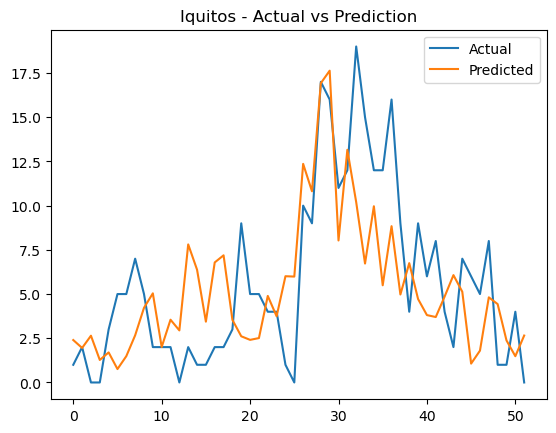

In [182]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(12,8))
plt.plot(y_iq_val.values, label = 'Actual')
plt.plot(y_pred_iq, label = 'Predicted')
plt.legend()
plt.title('Iquitos - Actual vs Prediction')

In [183]:
train_sj_train.columns

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases'],
      dtype='str')

In [184]:
train_sj_data = train_features[train_features['city'] == 'sj'].copy()
train_sj_data = train_sj_data.merge(
    train_labels,
    on=['city', 'year', 'weekofyear'],
    how='left'
)
train_sj_data = train_sj_data.sort_values(['year', 'weekofyear']).reset_index(drop=True)
train_sj_data = train_sj_data.ffill()
print('san juan training rows: ', train_sj_data.shape[0])
print('Missing values remaining: ', train_sj_data.isnull().sum().sum())
print('case count range: min =', train_sj_data['total_cases'].min(), "| max= ", train_sj_data['total_cases'].max())

san juan training rows:  936
Missing values remaining:  0
case count range: min = 0 | max=  461


In [185]:
for lag in range(1,17):
    train_sj_data[f'lag{lag}'] = (
        train_sj_data['total_cases'].shift(lag)
    )

train_sj_data = train_sj_data.dropna().reset_index(drop = True)
print('Rows after dropping NaN lag rows: ', train_sj_data.shape[0])
print(train_sj_data[['total_cases', 'lag1', 'lag2', 'lag3', 'lag4']].head(10))

Rows after dropping NaN lag rows:  920
   total_cases  lag1  lag2  lag3  lag4
0           21  13.0  23.0  17.0   6.0
1           28  21.0  13.0  23.0  17.0
2           24  28.0  21.0  13.0  23.0
3           20  24.0  28.0  21.0  13.0
4           40  20.0  24.0  28.0  21.0
5           27  40.0  20.0  24.0  28.0
6           42  27.0  40.0  20.0  24.0
7           33  42.0  27.0  40.0  20.0
8           43  33.0  42.0  27.0  40.0
9           37  43.0  33.0  42.0  27.0


In [186]:
train_sj_data['rolling_mean_4'] = (
    train_sj_data['total_cases']
    .shift(1)
    .rolling(window=4)
    .mean()
)
train_sj_data['rolling_mean_8'] = (
    train_sj_data['total_cases']
    .shift(1)
    .rolling(window=8)
    .mean()
)
train_sj_data['rolling_max_4'] = (
    train_sj_data['total_cases']
    .shift(1)
    .rolling(window=4)
    .max()
)
train_sj_data['rolling_std_4'] = (
    train_sj_data['total_cases']
    .shift(1)
    .rolling(window=4)
    .std()
)

train_sj_data = train_sj_data.dropna().reset_index(drop=True)
print('Rows after rolling stats: ', train_sj_data.shape[0])
print(train_sj_data[['total_cases', 'rolling_mean_4', 'rolling_max_4', 'rolling_std_4']].head(5))


Rows after rolling stats:  912
   total_cases  rolling_mean_4  rolling_max_4  rolling_std_4
0           43           35.50           42.0       6.855655
1           37           36.25           43.0       7.632169
2           57           38.75           43.0       4.645787
3           71           42.50           57.0      10.503968
4           44           52.00           71.0      15.187714


In [187]:
train_sj_data['week_sin'] = np.sin(2 * np.pi * train_sj_data['weekofyear'] / 52)
train_sj_data['week_cos'] = np.cos(2 * np.pi * train_sj_data['weekofyear'] / 52)
train_sj_data['trend'] = np.arange(len(train_sj_data))
print(train_sj_data[['weekofyear', 'week_sin', 'week_cos', 'trend']].head(10))

   weekofyear  week_sin  week_cos  trend
0          42 -0.935016  0.354605      0
1          43 -0.885456  0.464723      1
2          44 -0.822984  0.568065      2
3          45 -0.748511  0.663123      3
4          46 -0.663123  0.748511      4
5          47 -0.568065  0.822984      5
6          48 -0.464723  0.885456      6
7          49 -0.354605  0.935016      7
8          50 -0.239316  0.970942      8
9          51 -0.120537  0.992709      9


In [188]:
train_sj_data['humidity_lag4'] = (
    train_sj_data['reanalysis_specific_humidity_g_per_kg'].shift(4)
)
train_sj_data['humidity_lag8'] = (
    train_sj_data['reanalysis_specific_humidity_g_per_kg'].shift(8)
)
train_sj_data['precip_lag4'] = (
    train_sj_data['precipitation_amt_mm'].shift(4)
)
train_sj_data['precip_lag8'] = (
    train_sj_data['precipitation_amt_mm'].shift(8)
)
train_sj_data = train_sj_data.dropna().reset_index(drop=True)
print('Rows after climate lags: ', train_sj_data.shape[0])
print(train_sj_data[['precipitation_amt_mm', 'precip_lag4', 'precip_lag8', 'reanalysis_specific_humidity_g_per_kg', 'humidity_lag4', 'humidity_lag8']].head(5))

Rows after climate lags:  904
   precipitation_amt_mm  precip_lag4  precip_lag8  \
0                  0.00        20.00       143.55   
1                 52.45        20.04       127.03   
2                  0.00        33.61       101.35   
3                  0.00         9.96        20.46   
4                 15.85         0.00        20.00   

   reanalysis_specific_humidity_g_per_kg  humidity_lag4  humidity_lag8  
0                              13.615714      17.085714      18.115714  
1                              15.954286      16.752857      17.750000  
2                              13.682857      16.208571      18.034286  
3                              13.511429      16.161429      18.074286  
4                              14.671429      13.615714      17.085714  


In [189]:
split_index_sj = len(train_sj_data) - 52
train_sj_train = train_sj_data.iloc[:split_index_sj]
train_sj_val = train_sj_data.iloc[split_index_sj:]
features_sj = [col for col in train_sj_data.columns if col not in ['city', 'week_start_date', 'total_cases']]

X_sj_train = train_sj_train[features_sj]
X_sj_val = train_sj_val[features_sj]

y_sj_train_raw = train_sj_train['total_cases']
y_sj_val_raw = train_sj_val['total_cases']

y_sj_train_log = np.log1p(y_sj_train_raw)
y_sj_val_log = np.log1p(y_sj_val_raw)

print('Training rows: ', X_sj_train.shape[0])
print('Validation rows: ',X_sj_val.shape[0])
print('Number of features: ', len(features_sj))
print()
print('Raw cases stats:')
print(f'max = {y_sj_train.max()}, mean = {y_sj_train_raw.mean():.1f}')
print()
print('log transformed stats')
print(f'max = {y_sj_train_log.max():.3f} mean = {y_sj_train_log.mean():.3f}')
print()
print('Features being used: ', features_sj)




Training rows:  852
Validation rows:  52
Number of features:  49

Raw cases stats:
max = 461, mean = 34.4

log transformed stats
max = 6.136 mean = 3.008

Features being used:  ['year', 'weekofyear', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c', 'station_min_temp_c', 'station_precip_mm', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10', 'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'rolling_mean_4', 'rolling_mean_8', 'rolling_max_4', 'rolling_std_4', 'week_sin', 'week_cos', 'trend', 'humidity_lag4', 'humidity_lag8', 'precip_lag4', 'precip_lag8']


MODEL TRAINING FOR SAN JUAN

San jua MAE: 18.14
Best San Juan MAE: 9.383244514465332
Best params: {'n_estimators': 797, 'learning_rate': 0.026482214032242487, 'max_depth': 8, 'subsample': 0.6898659449352856, 'colsample_bytree': 0.7280401634684114, 'min_child_weight': 13, 'reg_alpha': 0.8600515948452141, 'reg_lambda': 1.8702534020881667}


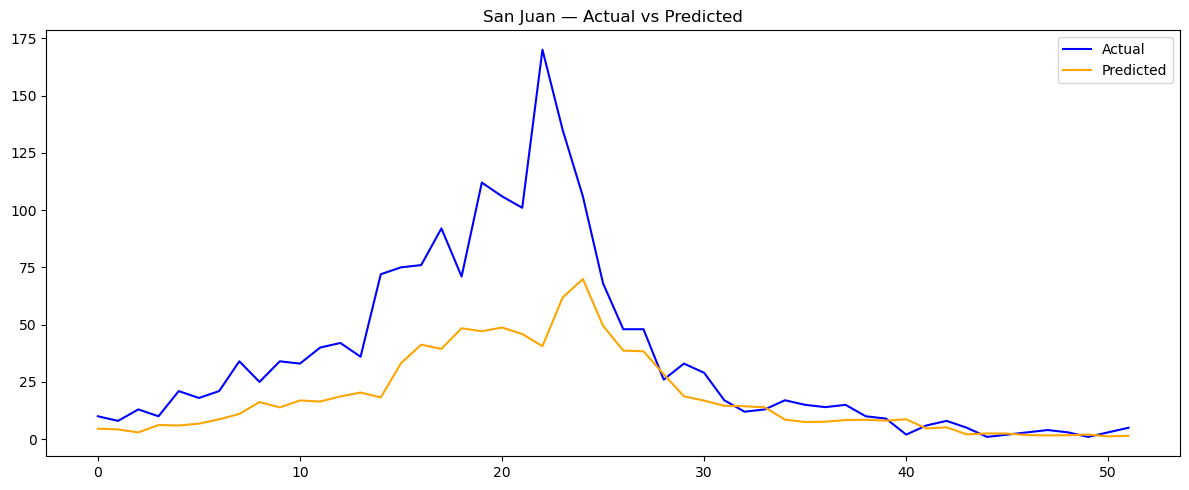

In [190]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
model_sj = XGBRegressor(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = 'count:poisson',
    min_child_weight = 5,
    random_state = 42
)
model_sj.fit(X_sj_train, y_sj_train_log)
y_pred_sj_log = model_sj.predict(X_sj_val)
y_pred_sj_real = np.expm1(y_pred_sj_log)
mae_sj = mean_absolute_error(y_sj_val_raw, y_pred_sj_real)
print(f'San jua MAE: {mae_sj:.2f}')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_sj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'objective': 'count:poisson',
        'random_state': 42
    }

    model = XGBRegressor(**params)
    # Train on log scale
    model.fit(X_sj_train, y_sj_train_log)
    # Predict and reverse log transform
    preds_log = model.predict(X_sj_val)
    preds_real = np.expm1(preds_log)
    # MAE on real scale — this is what Optuna minimises
    return mean_absolute_error(y_sj_val_raw, preds_real)

study_sj = optuna.create_study(direction='minimize')
study_sj.optimize(objective_sj, n_trials=100)

print("Best San Juan MAE:", study_sj.best_value)
print("Best params:", study_sj.best_params)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(y_sj_val_raw.values, label='Actual', color='blue')
plt.plot(y_pred_sj_real, label='Predicted', color='orange')
plt.title('San Juan — Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()


In [191]:
train_sj_data['outbreak_momentum'] = (
    train_sj_data['rolling_mean_4'] - train_sj_data['rolling_mean_8']
)

# We also add a binary flag — 1 if momentum is strongly positive, 0 otherwise
# threshold of 5 means "cases are rising by more than 5 per week on average"
# This gives the model a simple clear signal it can act on immediately
train_sj_data['outbreak_flag'] = (
    (train_sj_data['outbreak_momentum'] > 5).astype(int)
)

# Verify
print(train_sj_data[['total_cases', 'rolling_mean_4', 
                      'rolling_mean_8', 'outbreak_momentum', 
                      'outbreak_flag']].head(10))
print("\nOutbreak flag distribution:")
print(train_sj_data['outbreak_flag'].value_counts())

   total_cases  rolling_mean_4  rolling_mean_8  outbreak_momentum  \
0           47           51.25          51.625             -0.375   
1           26           52.00          52.125             -0.125   
2           27           44.50          50.750             -6.250   
3           21           38.00          47.000             -9.000   
4           21           30.25          40.750            -10.500   
5           26           23.75          37.875            -14.125   
6           34           23.75          34.125            -10.375   
7           37           25.50          31.750             -6.250   
8           17           29.50          29.875             -0.375   
9           19           28.50          26.125              2.375   

   outbreak_flag  
0              0  
1              0  
2              0  
3              0  
4              0  
5              0  
6              0  
7              0  
8              0  
9              0  

Outbreak flag distribution:
ou

In [192]:
print("IQ best MAE:", study.best_value)
print("IQ best params:", study.best_params)

IQ best MAE: 3.139439582824707
IQ best params: {'n_estimators': 1376, 'learning_rate': 0.034699567725631056, 'max_depth': 5, 'subsample': 0.9895003214243118, 'colsample_bytree': 0.9906009847740687, 'min_child_weight': 2, 'reg_alpha': 0.6116067454136923, 'reg_lambda': 2.475309636585978}


In [193]:
# ── Re-run split with new features included ──────────────────────

# Recalculate split — same logic, just picks up new columns automatically
split_index_sj = len(train_sj_data) - 52

train_sj_train = train_sj_data.iloc[:split_index_sj]
train_sj_val   = train_sj_data.iloc[split_index_sj:]

# Features list now automatically includes outbreak_momentum and outbreak_flag
features_sj = [col for col in train_sj_data.columns
                if col not in ['city', 'week_start_date', 'total_cases']]

X_sj_train = train_sj_train[features_sj]
X_sj_val   = train_sj_val[features_sj]

y_sj_train_raw = train_sj_train['total_cases']
y_sj_val_raw   = train_sj_val['total_cases']

y_sj_train_log = np.log1p(y_sj_train_raw)
y_sj_val_log   = np.log1p(y_sj_val_raw)

print("Features now:", len(features_sj))
print("New features added:", [f for f in features_sj if 'outbreak' in f])

# ── 200 trial Optuna with new features ───────────────────────────

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_sj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
        'objective': 'count:poisson',
        'random_state': 42
    }
    model = XGBRegressor(**params)
    model.fit(X_sj_train, y_sj_train_log)
    preds_real = np.expm1(model.predict(X_sj_val))
    return mean_absolute_error(y_sj_val_raw, preds_real)

study_sj = optuna.create_study(direction='minimize')
study_sj.optimize(objective_sj, n_trials=200)

print(f"Best San Juan MAE: {study_sj.best_value:.2f}")
print("Best params:", study_sj.best_params)

Features now: 51
New features added: ['outbreak_momentum', 'outbreak_flag']
Best San Juan MAE: 8.91
Best params: {'n_estimators': 1700, 'learning_rate': 0.03666369122028456, 'max_depth': 8, 'subsample': 0.7899405087899309, 'colsample_bytree': 0.9469376988640623, 'min_child_weight': 3, 'reg_alpha': 0.818142616583053, 'reg_lambda': 4.5200637199642415}


In [194]:
test_sj = test_features[test_features['city'] == 'sj'].copy()
test_iq = test_features[test_features['city'] == 'iq'].copy()

test_sj = test_sj.sort_values(['year', 'weekofyear']).reset_index(drop=True)
test_iq = test_iq.sort_values(['year', 'weekofyear']).reset_index(drop=True)

print("SJ test weeks:", len(test_sj))
print("IQ test weeks:", len(test_iq))
print("SJ test years:", test_sj['year'].unique())
print("IQ test years:", test_iq['year'].unique())

SJ test weeks: 260
IQ test weeks: 156
SJ test years: [2008 2009 2010 2011 2012 2013]
IQ test years: [2010 2011 2012 2013]


In [195]:
# ── Final Submission Builder ──────────────────────────────────────
import pandas as pd
import numpy as np


best_params_sj = study_sj.best_params.copy()
best_params_sj['objective'] = 'count:poisson'
best_params_sj['random_state'] = 42

X_sj_full = train_sj_data[features_sj]
y_sj_full  = np.log1p(train_sj_data['total_cases'])

model_sj_final = XGBRegressor(**best_params_sj)
model_sj_final.fit(X_sj_full, y_sj_full)
print("SJ final model trained on:", len(X_sj_full), "rows")

# IQ full retrain
# Rebuild IQ data cleanly the same way we built SJ
iq_data = train_features[train_features['city'] == 'iq'].copy()
iq_data = iq_data.merge(train_labels, on=['city', 'year', 'weekofyear'], how='left')
iq_data = iq_data.sort_values(['year', 'weekofyear']).reset_index(drop=True)
iq_data = iq_data.ffill()

# IQ lag features
for lag in range(1, 17):
    iq_data[f'lag{lag}'] = iq_data['total_cases'].shift(lag)

# IQ rolling stats
iq_data['rolling_mean_4'] = iq_data['total_cases'].shift(1).rolling(4).mean()
iq_data['rolling_mean_8'] = iq_data['total_cases'].shift(1).rolling(8).mean()
iq_data['rolling_max_4']  = iq_data['total_cases'].shift(1).rolling(4).max()
iq_data['rolling_std_4']  = iq_data['total_cases'].shift(1).rolling(4).std()

# IQ seasonal + trend
iq_data['week_sin'] = np.sin(2 * np.pi * iq_data['weekofyear'] / 52)
iq_data['week_cos'] = np.cos(2 * np.pi * iq_data['weekofyear'] / 52)
iq_data['trend']    = np.arange(len(iq_data))

# IQ climate lags
iq_data['humidity_lag4'] = iq_data['reanalysis_specific_humidity_g_per_kg'].shift(4)
iq_data['humidity_lag8'] = iq_data['reanalysis_specific_humidity_g_per_kg'].shift(8)
iq_data['precip_lag4']   = iq_data['precipitation_amt_mm'].shift(4)
iq_data['precip_lag8']   = iq_data['precipitation_amt_mm'].shift(8)

# IQ outbreak features
iq_data['outbreak_momentum'] = iq_data['rolling_mean_4'] - iq_data['rolling_mean_8']
iq_data['outbreak_flag']     = (iq_data['outbreak_momentum'] > 5).astype(int)

iq_data = iq_data.dropna().reset_index(drop=True)

# IQ feature list — same exclusions as SJ
features_iq = [col for col in iq_data.columns
               if col not in ['city', 'week_start_date', 'total_cases']]

X_iq_full = iq_data[features_iq]
y_iq_full = np.log1p(iq_data['total_cases'])

best_params_iq = study.best_params.copy()
best_params_iq['objective'] = 'count:poisson'
best_params_iq['random_state'] = 42

model_iq_final = XGBRegressor(**best_params_iq)
model_iq_final.fit(X_iq_full, y_iq_full)
print("IQ final model trained on:", len(X_iq_full), "rows")

SJ final model trained on: 904 rows
IQ final model trained on: 504 rows


In [196]:
def predict_city(test_df, train_df, model, features, city_name):
    recent_cases = list(train_df['total_cases'].values[-16:])
    
    test_df = test_df.sort_values(['year', 'weekofyear']).reset_index(drop=True)
    test_df = test_df.ffill()
    
    predictions = []
    
    for i in range(len(test_df)):
        row = test_df.iloc[i].copy()
        
        feature_row = {}

        for col in features:
            if col in test_df.columns:
                feature_row[col] = row[col]
        
        for lag in range(1, 17):
            col_name = f'lag{lag}'
            if col_name in features:
                feature_row[col_name] = recent_cases[-lag]
        
        # Build rolling stats from recent_cases
        if 'rolling_mean_4' in features:
            feature_row['rolling_mean_4'] = np.mean(recent_cases[-4:])
        if 'rolling_mean_8' in features:
            feature_row['rolling_mean_8'] = np.mean(recent_cases[-8:])
        if 'rolling_max_4' in features:
            feature_row['rolling_max_4']  = np.max(recent_cases[-4:])
        if 'rolling_std_4' in features:
            feature_row['rolling_std_4']  = np.std(recent_cases[-4:])
        
        # Seasonal encoding from actual week number
        if 'week_sin' in features:
            feature_row['week_sin'] = np.sin(2 * np.pi * row['weekofyear'] / 52)
        if 'week_cos' in features:
            feature_row['week_cos'] = np.cos(2 * np.pi * row['weekofyear'] / 52)
        
        # Trend — continues counting from where training ended
        if 'trend' in features:
            feature_row['trend'] = len(train_df) + i
        
        # Outbreak features from rolling stats we just computed
        if 'outbreak_momentum' in features:
            feature_row['outbreak_momentum'] = (
                feature_row.get('rolling_mean_4', 0) - 
                feature_row.get('rolling_mean_8', 0)
            )
        if 'outbreak_flag' in features:
            feature_row['outbreak_flag'] = (
                1 if feature_row.get('outbreak_momentum', 0) > 5 else 0
            )
        
        # Climate lags from recent test rows + training tail
        # We build a combined history of climate values
        if 'humidity_lag4' in features:
            feature_row['humidity_lag4'] = (
                test_df['reanalysis_specific_humidity_g_per_kg'].iloc[i-4] 
                if i >= 4 
                else train_df['reanalysis_specific_humidity_g_per_kg'].iloc[-(4-i)]
            )
        if 'humidity_lag8' in features:
            feature_row['humidity_lag8'] = (
                test_df['reanalysis_specific_humidity_g_per_kg'].iloc[i-8]
                if i >= 8
                else train_df['reanalysis_specific_humidity_g_per_kg'].iloc[-(8-i)]
            )
        if 'precip_lag4' in features:
            feature_row['precip_lag4'] = (
                test_df['precipitation_amt_mm'].iloc[i-4]
                if i >= 4
                else train_df['precipitation_amt_mm'].iloc[-(4-i)]
            )
        if 'precip_lag8' in features:
            feature_row['precip_lag8'] = (
                test_df['precipitation_amt_mm'].iloc[i-8]
                if i >= 8
                else train_df['precipitation_amt_mm'].iloc[-(8-i)]
            )
        
        # Convert feature row to dataframe for model input
        X_row = pd.DataFrame([feature_row])[features]
        
        # Predict — model outputs log scale, reverse with expm1
        pred_log  = model.predict(X_row)[0]
        pred_real = np.expm1(pred_log)
        
        # Round to integer and clip at 0 — cases can't be negative
        pred_int = max(0, int(round(pred_real)))
        predictions.append(pred_int)
        
        # CRITICAL: add this prediction to recent_cases
        # so next week's lag features use it
        recent_cases.append(pred_int)
    
    print(f"{city_name} predictions done — {len(predictions)} weeks")
    print(f"  min={min(predictions)}, max={max(predictions)}, mean={np.mean(predictions):.1f}")
    return predictions

# ── PART 3: Run predictions for both cities ───────────────────────

sj_preds = predict_city(test_sj, train_sj_data, model_sj_final, features_sj, 'SJ')
iq_preds = predict_city(test_iq, iq_data,       model_iq_final, features_iq, 'IQ')

# ── PART 4: Build submission dataframe ───────────────────────────

# DrivenData needs exactly 4 columns: city, year, weekofyear, total_cases
submission_sj = test_sj[['city', 'year', 'weekofyear']].copy()
submission_sj['total_cases'] = sj_preds

submission_iq = test_iq[['city', 'year', 'weekofyear']].copy()
submission_iq['total_cases'] = iq_preds

# Combine both cities — SJ rows first, then IQ rows
submission = pd.concat([submission_sj, submission_iq], ignore_index=True)

# Final checks before saving
print("\nSubmission shape:", submission.shape)
print("Cities:", submission['city'].unique())
print("Any nulls:", submission.isnull().sum().sum())
print("Any negative predictions:", (submission['total_cases'] < 0).sum())
print("\nFirst 5 rows:")
print(submission.head())
print("\nLast 5 rows:")
print(submission.tail())


submission.to_csv('dengai_submission.csv', index=False)
print("\nSubmission saved as dengai_submission.csv")
print("Total predictions:", len(submission))



SJ predictions done — 260 weeks
  min=1, max=23, mean=9.7
IQ predictions done — 156 weeks
  min=0, max=3, mean=1.0

Submission shape: (416, 4)
Cities: <StringArray>
['sj', 'iq']
Length: 2, dtype: str
Any nulls: 0
Any negative predictions: 0

First 5 rows:
  city  year  weekofyear  total_cases
0   sj  2008          18            2
1   sj  2008          19            1
2   sj  2008          20            2
3   sj  2008          21            4
4   sj  2008          22            7

Last 5 rows:
    city  year  weekofyear  total_cases
411   iq  2013          22            0
412   iq  2013          23            0
413   iq  2013          24            1
414   iq  2013          25            1
415   iq  2013          26            1

Submission saved as dengai_submission.csv
Total predictions: 416


In [197]:
train_sj_data.columns

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases', 'lag1',
       'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8', 'lag9', 'lag10',
       'lag11', 'lag12', 'lag13', 'lag14', 'lag15', 'lag16', 'rolling_mean_4',
       'rolling_mean_8', 'rolling_max_4', 'rolling_std_4', 'week_sin',
       'week_cos', 'trend', 'humidity_lag4', 'humidity_lag8', 'precip_lag4',
       'precip_lag8', 'outbreak_momentum', 'outbreak_flag'],
      d

In [200]:
# Run this in your notebook to see exact versions you used
import xgboost, optuna, sklearn, pandas, numpy, matplotlib
print(f"xgboost=={xgboost.__version__}")
print(f"optuna=={optuna.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"pandas=={pandas.__version__}")
print(f"numpy=={numpy.__version__}")
print(f"matplotlib=={matplotlib.__version__}")

xgboost==3.1.2
optuna==4.8.0
scikit-learn==1.7.1
pandas==3.0.0
numpy==2.4.2
matplotlib==3.10.8
